# ML-Assisted Detection of  IoT Botnet DDoS Attacks: An Ensemble Learning Approach

This notebook is part of the project that evulate the performance of ensemble model head-to-head on predeictive performance metric( accuracy, precision, F1-Score, and Recall), and Resource Utilization( Training and Inference CPU Utilization and time). The models considered as the following:

   - Random Forest
   - Extra Trees
   - AdaBoost
   - LightGBM
   - XGBoost
   - CatBoost
   
This specific notebook, uses the custom generated data to train the model. May refer to the read me on how CustomData was generated.


author: Kananelo Chabeli<br>
date: 01-04-2026

## Step 1. Module Imports

The first in programming, especially in python is to always import packages.

In [1]:
#Data Processing and Numerical Analyssis
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Data Preprocessing & Feature Engineering 
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.utils import resample

#Ensemble Learning Models 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
#Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

#Utility & System 
import os
import time
import warnings
import psutil
import threading
import joblib
import json
warnings.filterwarnings("ignore")


#Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
%matplotlib inline

## Step 2: Global Contants & Variables

In [2]:
#Path to where customDataset is stored, 
DATASET_PATH = "/home/chabeli/SDN_IoT/Dataset/Custom-Dataset" 

#This is where Model's Artefacts are all Saved!:
PARENT_DIRECTORY = '/home/chabeli/SDN_IoT/sdn-iot'

## Step 3: Data Preparation 

Data Preparation is extremely important step in Machine Learning. Our models will give correct predictions based on how good our data we fed them was.

This step involves removing empty, NULL, duplicates, scaling, feature dimensionality reduction, and many other steps.

### Step 3.1: Load Datasets 

Each Attacks has its own dataset. names ATTACK_TYPE.csv. The Benign traffic dataset is labelled: BENIGN.csv.

We load each sheet separately, then concatenate all into one dataframe. we sample then randomly to match the number  of samples generated in BENIGN traffic

In [3]:
csv_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")]
print(f"📂 Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"   └── {f}")

📂 Found 5 CSV files:
   └── ACK_FRAGMENTATION.csv
   └── BENIGN.csv
   └── ICMP_FLOOD.csv
   └── UDP_FLOOD.csv
   └── ICMP_FRAGMENTATION.csv


In [5]:
BENIGN_FILE  = "BENIGN.csv"
ATTACK_FILES = [
    "ICMP_FLOOD.csv",
    #"HTTP_FLOOD .csv",
    "ACK_FRAGMENTATION.csv",
    "ICMP_FRAGMENTATION.csv",
    #'SYN_FLOOD',
    'UDP_FLOOD.csv'
]

# #load BENIGN Traffc dataset to get the sample size.
benign_df = pd.read_csv(os.path.join(DATASET_PATH, BENIGN_FILE))
SAMPLE_SIZE = len(benign_df)

#We want to print, so that we can check if we doing correct things!
print(f"✅ Loaded Benign Traffic  →  Shape: {benign_df.shape}")
print(f"   Classes found         :  {benign_df['Label'].unique()}")
print(f"\n📏 Benchmark sample size (per class) : {SAMPLE_SIZE:,}\n")

# Load & downsample each attack file to match Benign size 
dataframes = [benign_df]

for file in ATTACK_FILES:
    filepath = os.path.join(DATASET_PATH, file)
    df_temp  = pd.read_csv(filepath)
    original_size = len(df_temp)

    # Sample min(available, SAMPLE_SIZE) to handle files smaller than benign
    n_samples = min(original_size, SAMPLE_SIZE)
    df_sampled = df_temp.sample(n=n_samples, random_state=42).reset_index(drop=True)
    
    #printing just makes things pretty
    print(f"✅ Loaded : {file}")
    print(f"   Original size  : {original_size:>10,}  →  Sampled: {n_samples:,}")
    print(f"   Classes found  : {df_sampled['Label'].unique()}\n")

    dataframes.append(df_sampled)

#Step 3: Concatenate & shuffle
df = pd.concat(dataframes, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

#Lets just print so that we can be sure than our things worked out pretty well
print(f"{'='*55}")
print(f"  ✅ Merged Dataset Shape  : {df.shape}")
print(f"  ✅ Total Classes         : {df['Label'].nunique()}")
print(f"\n  📊 Final Class Distribution:")
dist = df['Label'].value_counts()
for label, count in dist.items():
    print(f"    {label:<40} : {count:>8,}")
print(f"{'='*55}")

✅ Loaded Benign Traffic  →  Shape: (4480, 77)
   Classes found         :  ['BENIGN']

📏 Benchmark sample size (per class) : 4,480

✅ Loaded : ICMP_FLOOD.csv
   Original size  :      3,030  →  Sampled: 3,030
   Classes found  : ['ICMP_FLOOD']

✅ Loaded : ACK_FRAGMENTATION.csv
   Original size  :      2,608  →  Sampled: 2,608
   Classes found  : ['ACK_FRAGMENTATION']

✅ Loaded : ICMP_FRAGMENTATION.csv
   Original size  :      2,440  →  Sampled: 2,440
   Classes found  : ['ICMP_FRAGMENTATION']

✅ Loaded : UDP_FLOOD.csv
   Original size  :      2,420  →  Sampled: 2,420
   Classes found  : ['UDP_FLOOD']

  ✅ Merged Dataset Shape  : (14978, 77)
  ✅ Total Classes         : 5

  📊 Final Class Distribution:
    BENIGN                                   :    4,480
    ICMP_FLOOD                               :    3,030
    ACK_FRAGMENTATION                        :    2,608
    ICMP_FRAGMENTATION                       :    2,440
    UDP_FLOOD                                :    2,420


In [6]:
sizes = [ds.shape[0] for ds in dataframes]

sizes

[4480, 3030, 2608, 2440, 2420]

In [7]:
sum(sizes)

14978

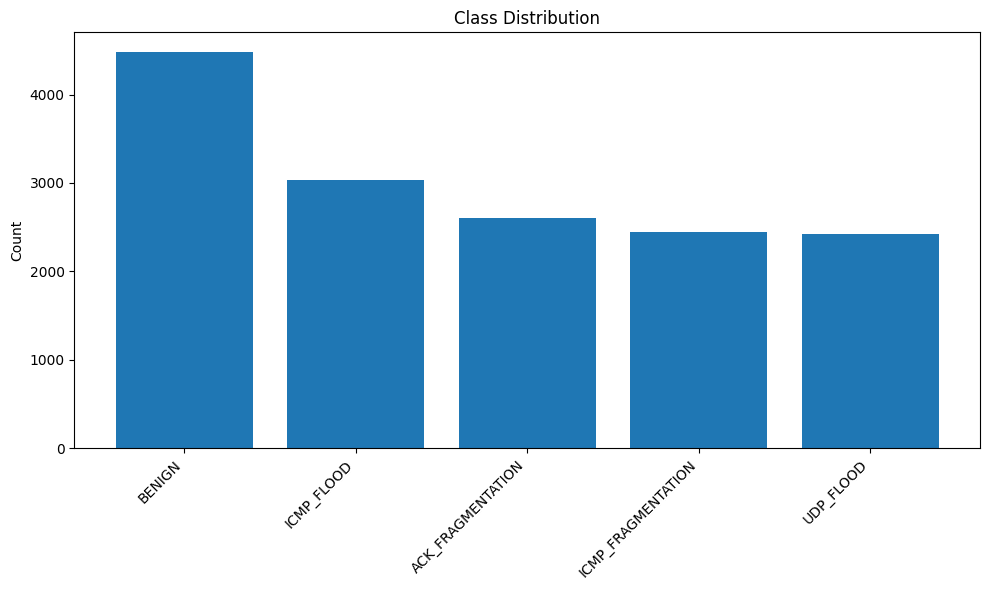

In [8]:
class_nums = [('BENIGN', 4480), ('ICMP_FLOOD', 3030), ('ACK_FRAGMENTATION', 2608), 
              ('ICMP_FRAGMENTATION', 2440),  ('UDP_FLOOD', 2420)]

labels, values = zip(*class_nums)

plt.figure(figsize=(10, 6))
plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:

df = df.sample(frac=1)
df

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
13779,1239000000.0000,619,0,70746,0,118.6000,110.8000,114.2908,1.7241,0,0,0,0,57.0993,0.4996,9.7301,0.0422,9.8333,9.6018,1239.0000,9.7301,0.0422,9.8333,9.6018,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12380,0,0.4996,0,110.8000,118.6000,114.2720,1.7241,2.9724,0,114.2720,114.2908,0,0,0,0,0,0,0,619,70746,0,0,65535,0,619,110.8000,1239.0000,0,1239.0000,1239.0000,0,0,0,0,BENIGN
686,139000000.0000,69,0,7912,0,118.8000,111.0000,114.6667,2.1573,0,0,0,0,56.9209,0.4964,9.7210,0.1729,10.1021,9.5511,139.0000,9.7210,0.1729,10.1021,9.5511,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1380,0,0.4964,0,111.0000,118.8000,114.6143,2.1573,4.6541,0,114.6143,114.6667,0,0,0,0,0,0,0,69,7912,0,0,7912,0,69,111.0000,139.0000,0,139.0000,139.0000,0,0,0,0,ICMP_FRAGMENTATION
7915,744000000.0000,372,0,42431,0,117.4000,110.2500,114.0618,1.7427,0,0,0,0,57.0309,0.5000,9.7500,0.0579,9.8737,9.6367,744.0000,9.7500,0.0579,9.8737,9.6367,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7440,0,0.5000,0,110.2500,117.4000,114.2463,1.7427,3.0371,0,114.2463,114.0618,0,0,0,0,0,0,0,372,42431,0,0,42431,0,372,110.2500,744.0000,0,744.0000,744.0000,0,0,0,0,ICMP_FLOOD
14763,444000000.0000,221,0,25231,0,121.0000,110.8000,114.1674,2.1125,0,0,0,0,56.8266,0.4977,9.8037,0.1171,10.2587,9.5617,444.0000,9.8037,0.1171,10.2587,9.5617,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4420,0,0.4977,0,110.8000,121.0000,114.3537,2.1125,4.4627,0,114.3537,114.1674,0,0,0,0,0,0,0,221,25231,0,0,25231,0,221,110.8000,444.0000,0,444.0000,444.0000,0,0,0,0,UDP_FLOOD
8349,954000000.0000,476,0,54426,0,118.0000,110.2000,114.3403,1.9756,0,0,0,0,57.0503,0.4990,9.7501,0.0643,9.8783,9.5712,954.0000,9.7501,0.0643,9.8783,9.5712,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9520,0,0.4990,0,110.2000,118.0000,114.3360,1.9756,3.9031,0,114.3360,114.3403,0,0,0,0,0,0,0,476,54426,0,0,54426,0,476,110.2000,954.0000,0,954.0000,954.0000,0,0,0,0,ICMP_FLOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14705,27000000.0000,12,0,1398,0,122.0000,112.0000,116.5000,2.2748,0,0,0,0,51.7778,0.4444,5.9032,3.3753,14.3053,0.7577,27.0000,5.9032,3.3753,14.3053,0.7577,0,0,0,0,0,0,0,0,0,0,0,0,0,79639,0,0,0,240,0,0.4444,0,112.0000,122.0000,115.5990,2.2748,5.1748,0,115.5990,116.5000,0,0,0,0,0,0,0,12,1398,0,0,1398,0,12,112.0000,27.0000,0,27.0000,27.0000,0,0,0,0,ACK_FRAGMENTATION
9392,183000000.0000,91,0,10441,0,120.4000,111.8000,114.7363,2.2596,0,0,0,0,57.0546,0.4973,9.7848,0.2047,10.3270,9.5249,183.0000,9.7848,0.2047,10.3270,9.5249,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1820,0,0.4973,0,111.8000,120.

### Step 3.2 Dataset Inspection and Sanity Check


It is often important to understand the structure of the dataset before even trying to implement the dataset.
Here you can answer questions such as 'How many duplicates rows do I have?'

In [10]:

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory Usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

#  Data types 
print("\n📋 Column Data Types:")
print(df.dtypes.value_counts())

# Missing values 
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing (%)", ascending=False)

print(f"\n🔍 Columns with Missing Values: {len(missing_report)}")
print(missing_report if not missing_report.empty else "   None found ✅")

# Infinite values 
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_report = inf_counts[inf_counts > 0]

print(f"\n🔍 Columns with Infinite Values: {len(inf_report)}")
print(inf_report if not inf_report.empty else "   None found ✅")

# Duplicate rows 
duplicate_count = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {duplicate_count:,}")

# Summary statistics
print("\n📊 Summary Statistics (numeric features):")
df.describe().T

  DATASET OVERVIEW
  Rows         : 14,978
  Columns      : 77
  Memory Usage : 10.25 MB

📋 Column Data Types:
int64      48
float64    28
object      1
Name: count, dtype: int64

🔍 Columns with Missing Values: 0
   None found ✅

🔍 Columns with Infinite Values: 0
   None found ✅

🔍 Duplicate Rows: 6,493

📊 Summary Statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
Flow Duration,14978.0000,733962812.1246,558914322.7333,1.0000,249750000.0000,644000000.0000,1104000000.0000,2240000000.0000
Total Fwd Packets,14978.0000,449.9990,3615.3294,3.0000,124.0000,322.0000,551.7500,163709.0000
Total Backward Packets,14978.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Total Length of Fwd Packets,14978.0000,50075.2041,354547.0020,333.0000,14213.7500,36721.0000,63006.2500,16043482.0000
Total Length of Bwd Packets,14978.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...
Active Min,14978.0000,733.9628,558.9143,0.0000,249.7500,644.0000,1104.0000,2240.0000
Idle Mean,14978.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Idle Std,14978.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Idle Max,14978.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Step 3.3: Data Cleaning

Here is where we handle missing values, infinities, and duplicate rows and/or columns

In [11]:

print("🧹 Starting Data Cleaning...\n")



# Replace inf/-inf with NaN
inf_before = np.isinf(df[numeric_cols]).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"  ♻️  Replaced {inf_before} infinite values with NaN")

#Drop flow ID, Src IP/Port, Dst IP/Port, Protocol columns
# df.drop(columns = ["Flow ID","Src IP", "Src Port", "Dst IP", "Dst Port", "Protocol","Timestamp"], 
#         inplace = True)

#Drop columns with >50% missing values
threshold = 0.50
cols_before = df.shape[1]
missing_pct_updated = df.isnull().mean()
cols_to_drop = missing_pct_updated[missing_pct_updated > threshold].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"  🗑️  Dropped {len(cols_to_drop)} columns exceeding {int(threshold*100)}% missing: {cols_to_drop}")

# Impute remaining NaNs with column median 
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f"  🔧 Imputed {nan_before} NaN values using column medians")

# Drop duplicate rows 
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  🗑️  Dropped {dupes_before:,} duplicate rows")

# Verify
print(f"\n{'='*55}")
print(f"  ✅ Cleaned Dataset Shape : {df.shape}")
print(f"  ✅ Remaining NaNs        : {df.isnull().sum().sum()}")
print(f"  ✅ Remaining Infs        : {np.isinf(df[numeric_cols]).sum().sum()}")
print(f"{'='*55}")

🧹 Starting Data Cleaning...

  ♻️  Replaced 0 infinite values with NaN
  🗑️  Dropped 0 columns exceeding 50% missing: []
  🔧 Imputed 0 NaN values using column medians
  🗑️  Dropped 6,493 duplicate rows

  ✅ Cleaned Dataset Shape : (8485, 77)
  ✅ Remaining NaNs        : 0
  ✅ Remaining Infs        : 0


### Step 3.4: Label Encoding

The 'Label' column contains string class names. We apply Label Encoding to convert these into integer class indices suitable for all models. A mapping dictionary is saved for interpretability and deployment use.

In [12]:
le = LabelEncoder()

df["Label_Encoded"] = le.fit_transform(df["Label"])

# Save class mapping 
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
reverse_mapping = {v: k for k, v in class_mapping.items()}

print("🏷️  Label Encoding Complete")
print(f"\n  Class Mapping:")
for class_name, code in class_mapping.items():
    count = (df["Label"] == class_name).sum()
    print(f"    [{code}]  {class_name:<25} →  {count:>10,} samples")

print(f"\n  Encoded label column: 'Label_Encoded'")
df[["Label", "Label_Encoded"]].value_counts().sort_index()

🏷️  Label Encoding Complete

  Class Mapping:
    [0]  ACK_FRAGMENTATION         →       2,218 samples
    [1]  BENIGN                    →       2,279 samples
    [2]  ICMP_FLOOD                →       1,519 samples
    [3]  ICMP_FRAGMENTATION        →       1,226 samples
    [4]  UDP_FLOOD                 →       1,243 samples

  Encoded label column: 'Label_Encoded'


Label               Label_Encoded
ACK_FRAGMENTATION   0                2218
BENIGN              1                2279
ICMP_FLOOD          2                1519
ICMP_FRAGMENTATION  3                1226
UDP_FLOOD           4                1243
Name: count, dtype: int64

### Step 3.5: Feature Engineering

With 73 features, we eliminate redundant ones in two passes:<br>
         - Pass 1 — Drop constant/near-constant features (zero/near-zero variance)<br>
         - Pass 2 — Drop one from each highly correlated pair (threshold r > 0.95)<br>
This reduces noise, speeds up training, and improves generalisation.

🔻 Pass 1 — Dropped 40 near-zero variance features:
   ['Total Backward Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Bwd Header Length', 'Bwd Packets/s', 'Down/Up Ratio', 'Avg Bwd Segment Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_backward', 'Active Std', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

🔻 Pass 2 — Dropped 22 highly correlated features (r > 0.95):
   ['Total Length of Fwd Packets', 'Flow Packets/s', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd 

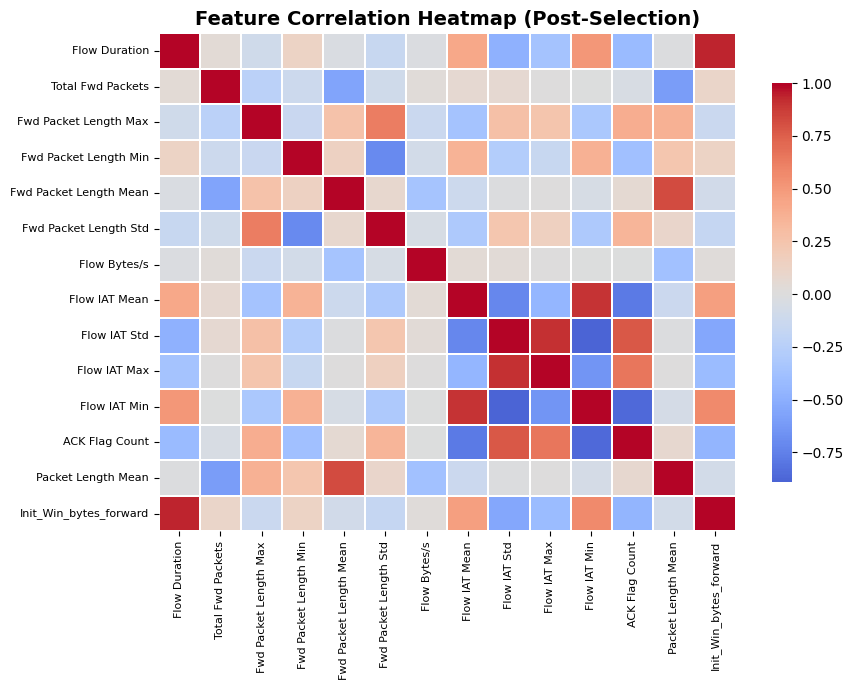

In [13]:

X_raw = df.drop(columns=["Label", "Label_Encoded"])
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

#Pass 1: Remove zero/near-zero variance features
variance = X_raw[numeric_cols].var()
low_var_cols = variance[variance < 0.01].index.tolist()
X_raw.drop(columns=low_var_cols, inplace=True)
print(f"🔻 Pass 1 — Dropped {len(low_var_cols)} near-zero variance features:")
print(f"   {low_var_cols}\n")

#Pass 2: Remove highly correlated features
THRESHOLD = 0.95
corr_matrix = X_raw.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > THRESHOLD)
]
X_raw.drop(columns=high_corr_cols, inplace=True)
print(f"🔻 Pass 2 — Dropped {len(high_corr_cols)} highly correlated features (r > {THRESHOLD}):")
print(f"   {high_corr_cols}\n")

print(f"{'='*55}")
print(f"  ✅ Features before selection : {df.shape[1] - 2}")
print(f"  ✅ Features after selection  : {X_raw.shape[1]}")
print(f"{'='*55}")

# Plot correlation heatmap (post-selection)
plt.figure(figsize=(9, 7))  # slightly bigger for readability

sns.heatmap(
    X_raw.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    xticklabels=X_raw.columns,
    yticklabels=X_raw.columns,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap (Post-Selection)", fontsize=14, fontweight="bold")

# Rotate labels for readability
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

### Step 3.6 Data Splitting: Train, Validation, and Evaluation split

In [14]:

X = X_raw.copy()
y = df["Label_Encoded"].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,          # 0.1765 × 0.85 ≈ 0.15 of total
    stratify=y_temp,
    random_state=42
)

print("📊 Dataset Split Summary:")
print(f"{'='*55}")
print(f"  Training Set   : {X_train.shape[0]:>10,} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation Set : {X_val.shape[0]:>10,} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test Set       : {X_test.shape[0]:>10,} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features       : {X_train.shape[1]}")
print(f"{'='*55}")

print("\n🏷️  Class Distribution Across Splits:")
split_dist = pd.DataFrame({
    "Train"      : y_train.map(reverse_mapping).value_counts(),
    "Validation" : y_val.map(reverse_mapping).value_counts(),
    "Test"       : y_test.map(reverse_mapping).value_counts(),
})
print(split_dist.fillna(0).astype(int))

📊 Dataset Split Summary:
  Training Set   :      5,939 samples  (70.0%)
  Validation Set :      1,273 samples  (15.0%)
  Test Set       :      1,273 samples  (15.0%)
  Features       : 14

🏷️  Class Distribution Across Splits:
                    Train  Validation  Test
Label_Encoded                              
BENIGN               1595         342   342
ACK_FRAGMENTATION    1552         333   333
ICMP_FLOOD           1063         228   228
UDP_FLOOD             871         186   186
ICMP_FRAGMENTATION    858         184   184


## Step 4: Define Helper Classes and Utilities

In [15]:
# Shared results store nerformance metrics of each model (populated by each model cell)
results = {
    "model"           : [],
    "train_time"      : [],
    "inference_time"  : [],
    "train_cpu"       : [],
    "inference_cpu"   : [],
    "accuracy"        : [],
    "precision"       : [],
    "recall"          : [],
    "f1"              : [],
}

#Dict of Model's
models = {}

In [16]:
#Thread that runs in the background and will extract each model's CPU usage information
class CPUMonitor:
    """Samples CPU usage in a background thread during a timed operation."""
    def __init__(self, interval=0.2):
        self.interval  = interval
        self.samples   = []
        self._stop     = threading.Event()
        self._thread   = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        while not self._stop.is_set():
            self.samples.append(psutil.cpu_percent(interval=None))
            time.sleep(self.interval)

    def start(self):
        psutil.cpu_percent(interval=None)   # warm-up reading (discard)
        self._thread.start()
        return self

    def stop(self):
        self._stop.set()
        self._thread.join()
        return round(np.mean(self.samples), 2) if self.samples else 0.0


In [17]:
def train_and_evaluate(name, model, X_tr, y_tr, X_vl, y_vl, X_te, y_te):
    """
    Trains a model, measures timing & CPU, computes metrics,
    logs everything to the shared results dict, and prints a report.
    """
    print(f"\n{'='*60}")
    print(f"  🌲 {name}")
    print(f"{'='*60}")

    # Training 
    cpu_train = CPUMonitor()
    cpu_train.start()
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = round(time.perf_counter() - t0, 4)
    avg_cpu_train = cpu_train.stop()

    print(f"  ⏱  Training Time    : {train_time:.4f}s")
    print(f"  🖥  Training CPU     : {avg_cpu_train:.2f}%")

    # Inference
    cpu_infer = CPUMonitor()
    cpu_infer.start()
    t1 = time.perf_counter()
    y_pred = model.predict(X_te)
    infer_time = round(time.perf_counter() - t1, 4)
    avg_cpu_infer = cpu_infer.stop()

    print(f"  ⏱  Inference Time   : {infer_time:.4f}s")
    print(f"  🖥  Inference CPU    : {avg_cpu_infer:.2f}%")

    # Metrics 
    acc  = round(accuracy_score(y_te, y_pred), 4)
    prec = round(precision_score(y_te, y_pred, average="weighted",
                                 zero_division=0), 4)
    rec  = round(recall_score(y_te, y_pred, average="weighted",
                               zero_division=0),4)
    f1   = round(f1_score(y_te, y_pred, average="weighted",
                           zero_division=0), 4)

    print(f"\n  📊 Metrics (Test Set):")
    print(f"     Accuracy  : {acc  * 100:.2f}%")
    print(f"     Precision : {prec * 100:.2f}%")
    print(f"     Recall    : {rec  * 100:.2f}%")
    print(f"     F1 Score  : {f1   * 100:.2f}%")

    # Per-class report 
    print(f"\n  📋 Classification Report:")
    print(classification_report(
        y_te, y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

    # Confusion matrix 
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    plt.xticks(rotation=30, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Append to shared results 
    results["model"].append(name)
    results["train_time"].append(train_time)
    results["inference_time"].append(infer_time)
    results["train_cpu"].append(avg_cpu_train)
    results["inference_cpu"].append(avg_cpu_infer)
    results["accuracy"].append(acc)
    results["precision"].append(prec)
    results["recall"].append(rec)
    results["f1"].append(f1)
    models[name] = model

    return model, y_pred


## Step 5: Train and Evaluate Ensemble Models

### Model 1: RandomForest


  🌲 Random Forest
  ⏱  Training Time    : 0.2978s
  🖥  Training CPU     : 30.40%
  ⏱  Inference Time   : 0.0432s
  🖥  Inference CPU    : 32.90%

  📊 Metrics (Test Set):
     Accuracy  : 99.37%
     Precision : 99.38%
     Recall    : 99.37%
     F1 Score  : 99.37%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      0.99      1.00       333
            BENIGN       0.99      1.00      0.99       342
        ICMP_FLOOD       0.99      1.00      0.99       228
ICMP_FRAGMENTATION       1.00      0.98      0.99       184
         UDP_FLOOD       0.98      1.00      0.99       186

          accuracy                           0.99      1273
         macro avg       0.99      0.99      0.99      1273
      weighted avg       0.99      0.99      0.99      1273



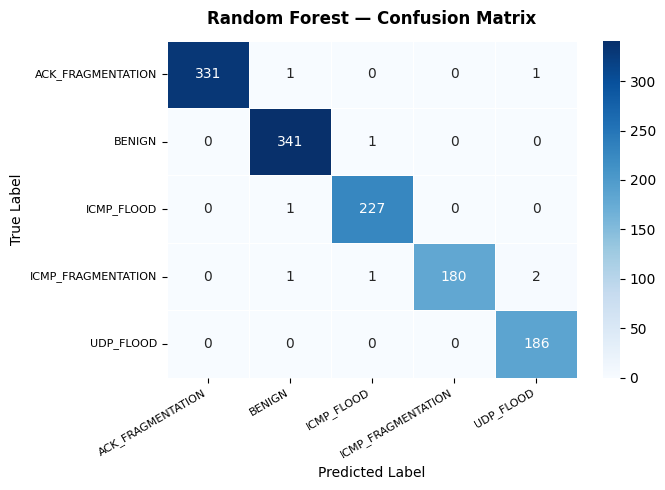

In [18]:
rf_model = RandomForestClassifier(
    n_estimators  = 50,
    criterion = 'entropy',
    max_depth     = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features  = "sqrt",
    class_weight  = "balanced",
    n_jobs        = -1,
    random_state  = 42,
    verbose       = 0
)

rf_model, rf_preds = train_and_evaluate(
    name  = "Random Forest",
    model = rf_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### Model 2: CatBoost


  🌲 CatBoost
  ⏱  Training Time    : 1.2634s
  🖥  Training CPU     : 62.44%
  ⏱  Inference Time   : 0.0049s
  🖥  Inference CPU    : 18.20%

  📊 Metrics (Test Set):
     Accuracy  : 99.61%
     Precision : 99.61%
     Recall    : 99.61%
     F1 Score  : 99.61%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      1.00      1.00       333
            BENIGN       0.99      0.99      0.99       342
        ICMP_FLOOD       1.00      1.00      1.00       228
ICMP_FRAGMENTATION       0.99      1.00      0.99       184
         UDP_FLOOD       0.99      0.99      0.99       186

          accuracy                           1.00      1273
         macro avg       1.00      1.00      1.00      1273
      weighted avg       1.00      1.00      1.00      1273



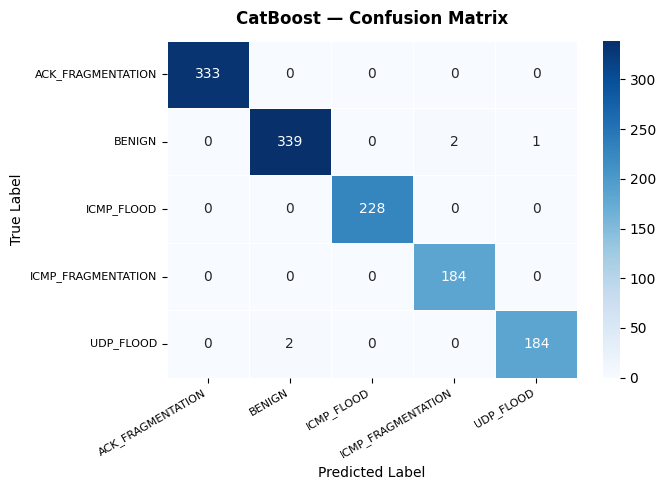

In [111]:
cat_model = CatBoostClassifier(
    iterations        = 300,
    depth             =4,
    random_seed       = 42,
    verbose           = 0              # suppress per-iteration logs
)

cat_model, cat_preds = train_and_evaluate(
    name     = "CatBoost",
    model    = cat_model,
    X_tr     = X_train,
    y_tr     = y_train,
    X_vl     = X_val,
    y_vl     = y_val,
    X_te     = X_test,
    y_te     = y_test)

### Model 3: ExtraTrees


  🌲 Extra Trees
  ⏱  Training Time    : 0.2172s
  🖥  Training CPU     : 17.65%
  ⏱  Inference Time   : 0.0528s
  🖥  Inference CPU    : 3.10%

  📊 Metrics (Test Set):
     Accuracy  : 99.45%
     Precision : 99.45%
     Recall    : 99.45%
     F1 Score  : 99.45%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      1.00      1.00       333
            BENIGN       1.00      0.99      0.99       342
        ICMP_FLOOD       1.00      1.00      1.00       228
ICMP_FRAGMENTATION       0.99      1.00      1.00       184
         UDP_FLOOD       0.98      0.99      0.99       186

          accuracy                           0.99      1273
         macro avg       0.99      1.00      0.99      1273
      weighted avg       0.99      0.99      0.99      1273



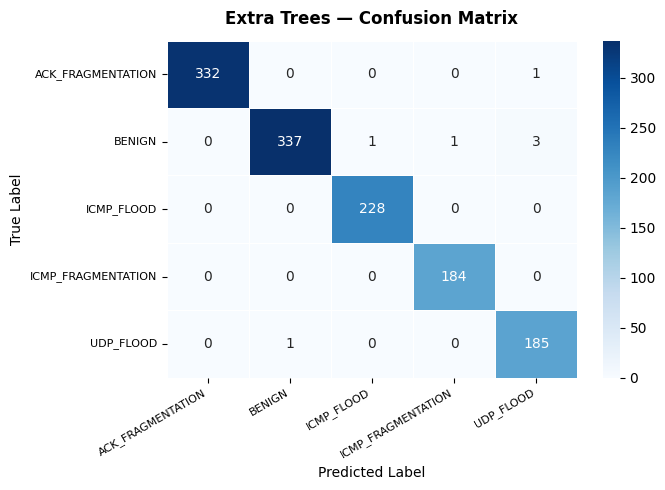

In [112]:
et_model = ExtraTreesClassifier(
    n_estimators      = 70,
    max_depth         = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = "sqrt",
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = 42,
    verbose           = 0)

et_model, et_preds = train_and_evaluate(
    name  = "Extra Trees",
    model = et_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test)

### Model 4: AdaBoost(Adaptive Boosting)


  🌲 AdaBoost
  ⏱  Training Time    : 1.8604s
  🖥  Training CPU     : 12.84%
  ⏱  Inference Time   : 0.0240s
  🖥  Inference CPU    : 3.70%

  📊 Metrics (Test Set):
     Accuracy  : 97.41%
     Precision : 97.44%
     Recall    : 97.41%
     F1 Score  : 97.41%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      1.00      1.00       333
            BENIGN       0.95      0.96      0.96       342
        ICMP_FLOOD       0.94      0.98      0.96       228
ICMP_FRAGMENTATION       0.99      1.00      0.99       184
         UDP_FLOOD       0.99      0.93      0.96       186

          accuracy                           0.97      1273
         macro avg       0.98      0.97      0.97      1273
      weighted avg       0.97      0.97      0.97      1273



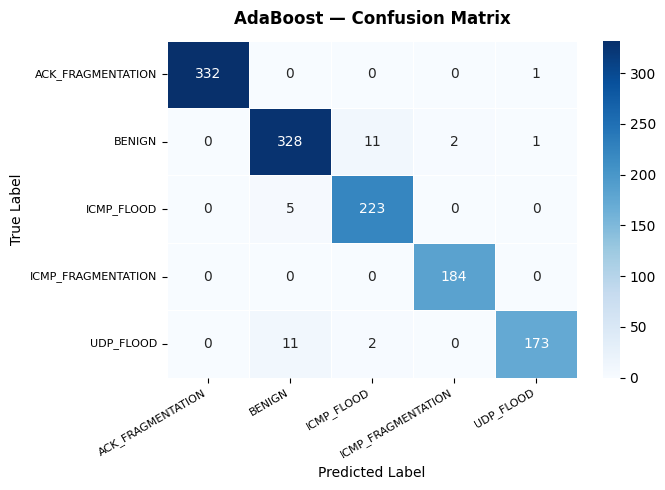

In [113]:
adaboost_base = DecisionTreeClassifier(
    max_depth    = 4,
    random_state = 42
)

ada_model = AdaBoostClassifier(
    estimator        = adaboost_base,
    n_estimators     = 50,
    learning_rate    = 0.2,
    algorithm        = "SAMME",
    random_state     = 42
)

ada_model, ada_preds = train_and_evaluate(
    name  = "AdaBoost",
    model = ada_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### Model 5: LightGBM(Light Gradient Boosting Machine)


  🌲 LightGBM
  ⏱  Training Time    : 6.1826s
  🖥  Training CPU     : 51.00%
  ⏱  Inference Time   : 0.0816s
  🖥  Inference CPU    : 28.40%

  📊 Metrics (Test Set):
     Accuracy  : 99.76%
     Precision : 99.77%
     Recall    : 99.76%
     F1 Score  : 99.76%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      1.00      1.00       333
            BENIGN       1.00      0.99      1.00       342
        ICMP_FLOOD       1.00      1.00      1.00       228
ICMP_FRAGMENTATION       0.99      1.00      0.99       184
         UDP_FLOOD       0.99      1.00      1.00       186

          accuracy                           1.00      1273
         macro avg       1.00      1.00      1.00      1273
      weighted avg       1.00      1.00      1.00      1273



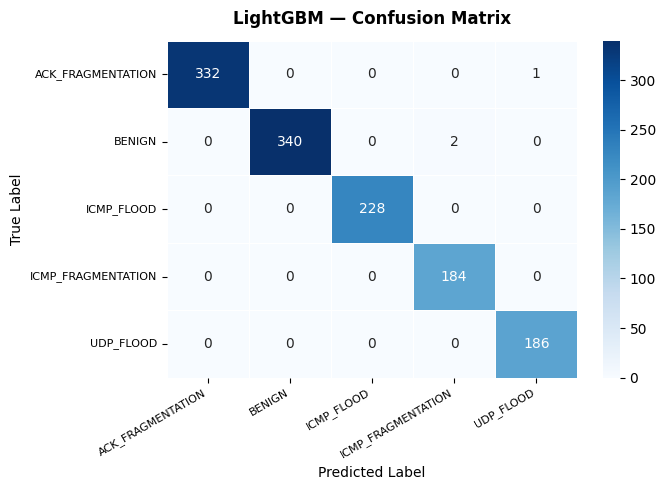

In [114]:
lgbm_model = LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = -1,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = 42,
    verbose           = -1
)

lgbm_model, lgbm_preds = train_and_evaluate(
    name  = "LightGBM",
    model = lgbm_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)


### Model 6: XGBoost(eXtreme Gradient Boosting)


  🌲 XGBoost
  ⏱  Training Time    : 3.6000s
  🖥  Training CPU     : 94.34%
  ⏱  Inference Time   : 0.0296s
  🖥  Inference CPU    : 73.50%

  📊 Metrics (Test Set):
     Accuracy  : 99.69%
     Precision : 99.69%
     Recall    : 99.69%
     F1 Score  : 99.69%

  📋 Classification Report:
                    precision    recall  f1-score   support

 ACK_FRAGMENTATION       1.00      1.00      1.00       333
            BENIGN       1.00      0.99      1.00       342
        ICMP_FLOOD       1.00      1.00      1.00       228
ICMP_FRAGMENTATION       0.99      1.00      1.00       184
         UDP_FLOOD       0.99      1.00      0.99       186

          accuracy                           1.00      1273
         macro avg       1.00      1.00      1.00      1273
      weighted avg       1.00      1.00      1.00      1273



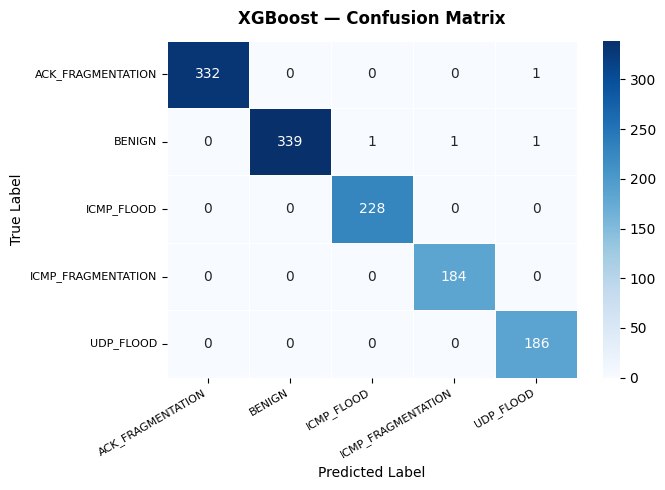

In [115]:
xgb_model = XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    verbose           = -1
)

xgb_model, lgbm_preds = train_and_evaluate(
    name  = "XGBoost",
    model = xgb_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

## Step 6: Results Summary

In [116]:

results_df = pd.DataFrame(results)

# Convert to percentages for readability
results_df["accuracy"]  = results_df["accuracy"]  * 100
results_df["precision"] = results_df["precision"] * 100
results_df["recall"]    = results_df["recall"]    * 100
results_df["f1"]        = results_df["f1"]        * 100

# Rank by F1 
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
results_df.index += 1                     # rank starts at 1

# Rename columns for display 
display_df = results_df.rename(columns={
    "model"          : "Model",
    "train_time"     : "Train Time (s)",
    "inference_time" : "Infer Time (s)",
    "train_cpu"      : "Train CPU (%)",
    "inference_cpu"  : "Infer CPU (%)",
    "accuracy"       : "Accuracy (%)",
    "precision"      : "Precision (%)",
    "recall"         : "Recall (%)",
    "f1"             : "F1 Score (%)",
})

print("🏆 Ensemble Model Comparison — Ranked by F1 Score")
print("=" * 175)
print(display_df.to_string(index=True))
print("=" * 175)
print(f"\n🥇 Best Model : {results_df.iloc[0]['model']}")
print(f"   F1 Score   : {results_df.iloc[0]['f1']:.2f}%")
print(f"   Accuracy   : {results_df.iloc[0]['accuracy']:.2f}%")

# Save results for visualisation 
results_df.to_csv("ensemble_results.csv", index=False)
print("\n💾 Results saved to ensemble_results.csv")

🏆 Ensemble Model Comparison — Ranked by F1 Score
           Model  Train Time (s)  Infer Time (s)  Train CPU (%)  Infer CPU (%)  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
1       LightGBM          6.1826          0.0816        51.0000        28.4000       99.7600        99.7700     99.7600       99.7600
2        XGBoost          3.6000          0.0296        94.3400        73.5000       99.6900        99.6900     99.6900       99.6900
3       CatBoost          1.2634          0.0049        62.4400        18.2000       99.6100        99.6100     99.6100       99.6100
4  Random Forest          0.2871          0.0433        34.5500        26.7000       99.6100        99.6100     99.6100       99.6100
5    Extra Trees          0.2172          0.0528        17.6500         3.1000       99.4500        99.4500     99.4500       99.4500
6       AdaBoost          1.8604          0.0240        12.8400         3.7000       97.4100        97.4400     97.4100       97.4100

🥇 Best Model

# Future Works:

Prepare the model for deployment in real SDN environment

### Step 7.1: Check Feature Importance

In [117]:
best_idx = max(range(len(results["f1"])), key=lambda i: results["f1"][i])
best_model_name = results["model"][best_idx]

print(best_model_name)

LightGBM


Feature importance on the Best Model:
               feature  importance
         Flow IAT Mean        8551
          Flow IAT Min        7887
         Flow Duration        5783
          Flow IAT Max        5074
          Flow IAT Std        4939
     Total Fwd Packets        3703
 Fwd Packet Length Std        3602
          Flow Bytes/s        3349
 Fwd Packet Length Min        3343
 Fwd Packet Length Max        3289
Init_Win_bytes_forward        2922
Fwd Packet Length Mean        2810
    Packet Length Mean        2582
        ACK Flag Count         315


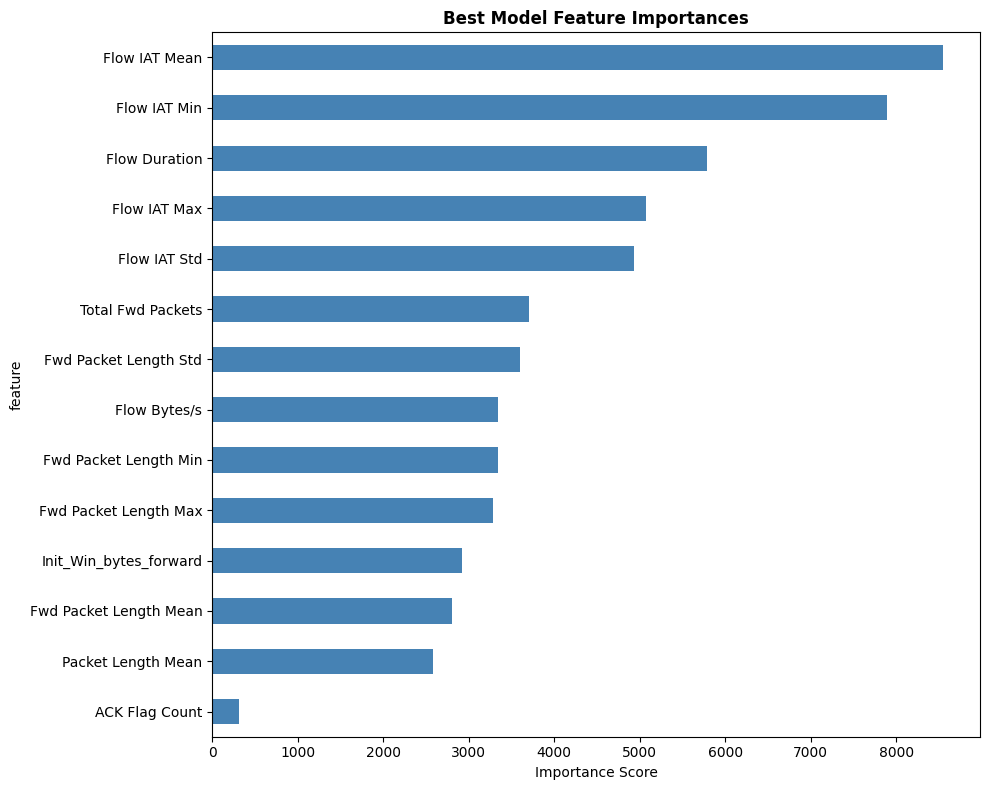


✅ Top features saved for controller use.


In [118]:
best_model = models[best_model_name]
importances =best_model.feature_importances_
feature_names = X_raw.columns.tolist()

feat_imp_df = pd.DataFrame({
    "feature"    : feature_names,
    "importance" : importances
}).sort_values("importance", ascending=False).head(20)

print("Feature importance on the Best Model:")
print(feat_imp_df.to_string(index=False))

feat_imp_df.plot(
    kind="barh", x="feature", y="importance",
    figsize=(10, 8), color="steelblue", legend=False
)
plt.title("Best Model Feature Importances", fontweight="bold")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=150)
plt.show()
os.makedirs(PARENT_DIRECTORY+"/preprocessed", exist_ok=True)
# Save top features list for controller use
top_features = feat_imp_df["feature"].tolist()
joblib.dump(top_features, f"{PARENT_DIRECTORY}/preprocessed/top_features.pkl")
print("\n✅ Top features saved for controller use.")

### Step 7.2 Save Best Model's ARTEFACTS for SDN-IoT Deployment

In [98]:
print("💾 Saving model artefacts for SDN-IoT controller deployment...\n")

ARTEFACT_DIR = PARENT_DIRECTORY+"/preprocessed"
joblib.dump(best_model, f"{ARTEFACT_DIR}/best_model.pkl")
print(f"  ✅ Best model saved          → best_model.pkl")
print(f"     Estimators              : {best_model.n_estimators}")
print(f"     Features expected       : {best_model.n_features_in_}")
print(f"     Classes                 : {best_model.n_classes_}")


joblib.dump(le, f"{ARTEFACT_DIR}/label_encoder.pkl")
print(f"\n  ✅ Label encoder saved     → label_encoder.pkl")
for idx, cls in enumerate(le.classes_):
    print(f"     [{idx}] {cls}")


# joblib.dump(scaler, f"{ARTEFACT_DIR}/scaler.pkl")
# print(f"\n  ✅ Scaler saved            → scaler.pkl")
# print(f"     Type                    : {type(scaler).__name__}")
# print(f"     Feature count           : {scaler.n_features_in_}")


selected_features = X_raw.columns.tolist()
joblib.dump(selected_features, f"{ARTEFACT_DIR}/selected_features.pkl")
print(f"\n  ✅ Selected features saved → selected_features.pkl")
print(f"     Feature count           : {len(selected_features)}")


class_mapping   = {cls: int(idx) for idx, cls in enumerate(le.classes_)}
reverse_mapping = {int(idx): cls for idx, cls in enumerate(le.classes_)}

joblib.dump(class_mapping,   f"{ARTEFACT_DIR}/class_mapping.pkl")
joblib.dump(reverse_mapping, f"{ARTEFACT_DIR}/reverse_mapping.pkl")

with open(f"{ARTEFACT_DIR}/class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=2)
with open(f"{ARTEFACT_DIR}/reverse_mapping.json", "w") as f:
    json.dump(reverse_mapping, f, indent=2)

print(f"\n  ✅ Class mappings saved    → class_mapping.pkl / .json")
print(f"                             → reverse_mapping.pkl / .json")


importances    = best_model.feature_importances_
feat_imp_df    = pd.DataFrame({
    "feature"    : selected_features,
    "importance" : importances
}).sort_values("importance", ascending=False)

top_features   = feat_imp_df["feature"].tolist()
top_20_features = feat_imp_df.head(20)["feature"].tolist()

joblib.dump(top_features,    f"{ARTEFACT_DIR}/top_features.pkl")
joblib.dump(top_20_features, f"{ARTEFACT_DIR}/top_20_features.pkl")


feat_imp_df.to_csv(f"{ARTEFACT_DIR}/feature_importances.csv", index=False)

print(f"\n  ✅ Feature importances saved → top_features.pkl")
print(f"                               → top_20_features.pkl")
print(f"                               → feature_importances.csv")
print(f"\n  Top 10 most important features:")
for i, row in feat_imp_df.head(10).iterrows():
    print(f"     {row['feature']:<45} : {row['importance']:.6f}")

    
benign_idx = int(list(le.classes_).index("BENIGN"))
joblib.dump(benign_idx, f"{ARTEFACT_DIR}/benign_class_idx.pkl")
print(f"\n  ✅ Benign class index saved → benign_class_idx.pkl")
print(f"     BenignTraffic index     : {benign_idx}")


DEPLOYMENT_THRESHOLD = 0.85
joblib.dump(DEPLOYMENT_THRESHOLD, f"{ARTEFACT_DIR}/confidence_threshold.pkl")

with open(f"{ARTEFACT_DIR}/confidence_threshold.json", "w") as f:
    json.dump({"confidence_threshold": DEPLOYMENT_THRESHOLD}, f, indent=2)

print(f"\n  ✅ Confidence threshold saved → confidence_threshold.pkl / .json")
print(f"     Threshold               : {DEPLOYMENT_THRESHOLD}")


zero_vector = np.zeros(len(selected_features), dtype=np.float32)
joblib.dump(zero_vector, f"{ARTEFACT_DIR}/zero_feature_vector.pkl")
print(f"\n  ✅ Zero feature vector saved → zero_feature_vector.pkl")
print(f"     Shape                   : {zero_vector.shape}")


manifest = {
    "model"              : "best_model.pkl",
    "label_encoder"      : "label_encoder.pkl",
    "scaler"             : "scaler.pkl",
    "selected_features"  : "selected_features.pkl",
    "class_mapping"      : "class_mapping.pkl",
    "reverse_mapping"    : "reverse_mapping.pkl",
    "top_features"       : "top_features.pkl",
    "top_20_features"    : "top_20_features.pkl",
    "benign_class_idx"   : "benign_class_idx.pkl",
    "confidence_threshold": "confidence_threshold.pkl",
    "zero_feature_vector": "zero_feature_vector.pkl",
    "n_features"         : len(selected_features),
    "n_classes"          : len(le.classes_),
    "classes"            : list(le.classes_),
    "benign_label"       : "BenignTraffic",
    "benign_class_idx"   : benign_idx,
    "confidence_threshold_value" : DEPLOYMENT_THRESHOLD,
}

with open(f"{ARTEFACT_DIR}/artefact_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n  ✅ Manifest saved           → artefact_manifest.json")

saved_files = os.listdir(ARTEFACT_DIR)
total_size  = sum(
    os.path.getsize(os.path.join(ARTEFACT_DIR, f))
    for f in saved_files
) / 1e6

print(f"\n{'='*60}")
print(f"  ✅ All artefacts saved successfully!")
print(f"  📁 Directory    : {ARTEFACT_DIR}")
print(f"  📦 Files saved  : {len(saved_files)}")
print(f"  💽 Total size   : {total_size:.2f} MB")
print(f"{'='*60}")
print(f"\n  Next step: copy artefacts to ~/pox/ext/artefacts/")
print(f"  cp -r {ARTEFACT_DIR}/* ~/pox/ext/artefacts/")


💾 Saving model artefacts for SDN-IoT controller deployment...

  ✅ Best model saved          → best_model.pkl
     Estimators              : 500
     Features expected       : 14
     Classes                 : 5

  ✅ Label encoder saved     → label_encoder.pkl
     [0] ACK_FRAGMENTATION
     [1] BENIGN
     [2] ICMP_FLOOD
     [3] ICMP_FRAGMENTATION
     [4] UDP_FLOOD

  ✅ Selected features saved → selected_features.pkl
     Feature count           : 14

  ✅ Class mappings saved    → class_mapping.pkl / .json
                             → reverse_mapping.pkl / .json

  ✅ Feature importances saved → top_features.pkl
                               → top_20_features.pkl
                               → feature_importances.csv

  Top 10 most important features:
     Flow IAT Mean                                 : 8827.000000
     Flow IAT Min                                  : 7902.000000
     Flow Duration                                 : 5807.000000
     Flow IAT Max                   